# BayesNF k-fold -- ELBO convergence curves

Per-fold loss curves of the five spatial k-fold VI runs. Used as a
sanity check for the final-model loss plot
(`final/final_loss_plot.ipynb`).

```
s3://thesis-data-ismaktam/bayesnf/runs/vi__kfold{0..4}__WY_h1_10__ffrk_full/
    losses.npy
```


## 1. Setup


In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import boto3

ROOT = Path('../../..').resolve()
os.chdir(ROOT)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

s3 = boto3.client('s3')
print(f'cwd: {os.getcwd()}')


cwd: /Users/etomengoi/Desktop/precip_interpolation_thesis


## 2. Config


In [2]:
S3_BUCKET    = 'thesis-data-ismaktam'
S3_RUNS_ROOT = 'bayesnf/runs'

FOLDS  = [0, 1, 2, 3, 4]
SUFFIX = 'WY_h1_10__ffrk_full'

LOCAL_RUNS = Path('results/bayesnf/runs')
LOCAL_RUNS.mkdir(parents=True, exist_ok=True)

OUT_PNG = Path('results/bayesnf/kfold_losses.png')
OUT_PDF = Path('thesis/text/images/06/bnf_kfold_losses.pdf')
OUT_PNG.parent.mkdir(parents=True, exist_ok=True)
OUT_PDF.parent.mkdir(parents=True, exist_ok=True)

print(f'folds: {FOLDS}')
print(f'png  : {OUT_PNG}')
print(f'pdf  : {OUT_PDF}')


folds: [0, 1, 2, 3, 4]
png  : results/bayesnf/kfold_losses.png
pdf  : thesis/text/images/06/bnf_kfold_losses.pdf


## 3. Download artifacts


In [3]:
def _ensure_local(run_name: str, fname: str) -> Path:
    local_dir = LOCAL_RUNS / run_name
    local_dir.mkdir(parents=True, exist_ok=True)
    local = local_dir / fname
    if local.exists():
        print(f'  cache hit: {run_name}/{fname} ({local.stat().st_size/1e6:.2f} MB)')
        return local
    key = f'{S3_RUNS_ROOT}/{run_name}/{fname}'
    print(f'  downloading s3://{S3_BUCKET}/{key} ...')
    s3.download_file(S3_BUCKET, key, str(local))
    print(f'  downloaded: {run_name}/{fname} ({local.stat().st_size/1e6:.2f} MB)')
    return local

losses_paths = {}
configs      = {}
for k in FOLDS:
    name = f'vi__kfold{k}__{SUFFIX}'
    losses_paths[k] = _ensure_local(name, 'losses.npy')
    configs[k]      = json.loads(_ensure_local(name, 'config.json').read_text())

N_EPOCHS = configs[0]['num_epochs']
assert all(c['num_epochs'] == N_EPOCHS for c in configs.values())
print(f'\nnum_epochs (all folds): {N_EPOCHS}')


  cache hit: vi__kfold0__WY_h1_10__ffrk_full/losses.npy (1.11 MB)
  cache hit: vi__kfold0__WY_h1_10__ffrk_full/config.json (0.00 MB)
  cache hit: vi__kfold1__WY_h1_10__ffrk_full/losses.npy (1.11 MB)
  cache hit: vi__kfold1__WY_h1_10__ffrk_full/config.json (0.00 MB)
  cache hit: vi__kfold2__WY_h1_10__ffrk_full/losses.npy (1.11 MB)
  cache hit: vi__kfold2__WY_h1_10__ffrk_full/config.json (0.00 MB)
  cache hit: vi__kfold3__WY_h1_10__ffrk_full/losses.npy (1.11 MB)
  cache hit: vi__kfold3__WY_h1_10__ffrk_full/config.json (0.00 MB)
  cache hit: vi__kfold4__WY_h1_10__ffrk_full/losses.npy (1.11 MB)
  cache hit: vi__kfold4__WY_h1_10__ffrk_full/config.json (0.00 MB)

num_epochs (all folds): 100


## 4. Load and reshape

Each `losses.npy` has shape `(num_devices, ensemble_per_device, n_steps)`.
We flatten the first two axes so each row is one VI member.


In [4]:
losses = {}
for k, p in losses_paths.items():
    raw = np.load(p)
    flat = raw.reshape(-1, raw.shape[-1])
    losses[k] = flat
    print(f'fold {k}: raw {raw.shape} -> {flat.shape}  '
          f'(first {flat.mean(0)[0]:.3e}, final {flat.mean(0)[-1]:.3e})')


fold 0: raw (4, 8, 8700) -> (32, 8700)  (first 4.361e+07, final 9.612e+06)
fold 1: raw (4, 8, 8700) -> (32, 8700)  (first 4.465e+07, final 9.781e+06)
fold 2: raw (4, 8, 8700) -> (32, 8700)  (first 4.463e+07, final 9.755e+06)
fold 3: raw (4, 8, 8700) -> (32, 8700)  (first 4.411e+07, final 9.659e+06)
fold 4: raw (4, 8, 8700) -> (32, 8700)  (first 4.424e+07, final 9.709e+06)


## 5. Plot

Two panels (linear, log). Each fold drawn as a faint envelope of its
$32$ VI members plus the per-fold ensemble mean.


wrote: results/bayesnf/kfold_losses.png
wrote: thesis/text/images/06/bnf_kfold_losses.pdf


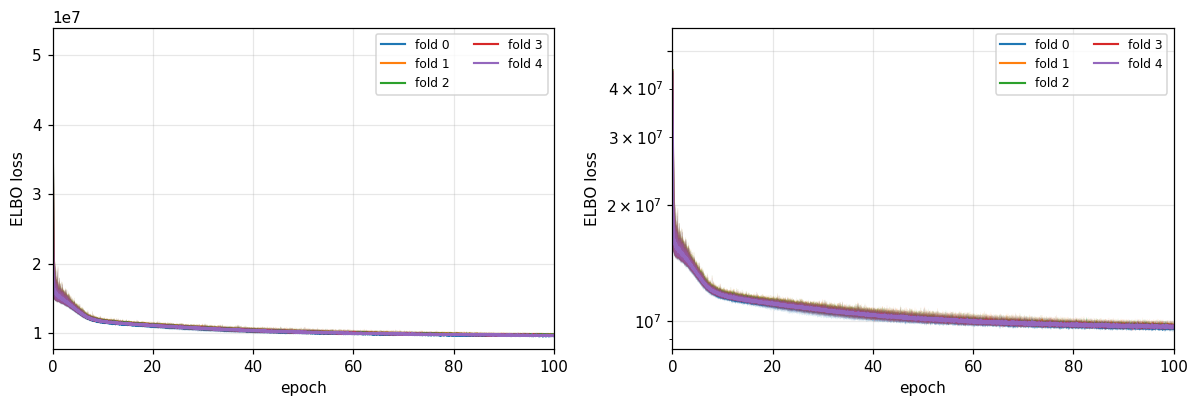

In [5]:
palette = plt.get_cmap('tab10')
y_min = min(L.min() for L in losses.values())
y_max = max(L.max() for L in losses.values())
y_pad = 0.04 * (y_max - y_min)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for ax, use_log in zip(axes, [False, True]):
    for k, L in losses.items():
        n_steps = L.shape[1]
        epoch_axis = np.arange(n_steps) / (n_steps / N_EPOCHS)
        col = palette(k)
        for m in range(L.shape[0]):
            ax.plot(epoch_axis, L[m], color=col, alpha=0.06, lw=0.4)
        ax.plot(epoch_axis, L.mean(0), color=col, lw=1.4,
                label=f'fold {k}')
    ax.set_xlabel('epoch')
    ax.set_ylabel('ELBO loss')
    ax.set_xlim(0, N_EPOCHS)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    if use_log:
        ax.set_yscale('log')
        ax.set_ylim(y_min * 0.9, y_max * 1.1)
        ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0, 2.0, 5.0)))
        ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10.0))
    else:
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

plt.tight_layout()
plt.savefig(OUT_PNG, bbox_inches='tight', pad_inches=0.1)
plt.savefig(OUT_PDF, bbox_inches='tight', pad_inches=0.1)
print(f'wrote: {OUT_PNG}')
print(f'wrote: {OUT_PDF}')
plt.show()
